In [1]:
!pip -q install shap

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

np.random.seed(42)
n = 600

engine_size = np.random.uniform(1.0, 4.0, n)
horsepower = 70 + engine_size*45 + np.random.normal(0,15,n)
weight = 900 + engine_size*320 + np.random.normal(0,90,n)
age = np.random.uniform(0,15,n)
mileage = age*np.random.uniform(8000,18000,n)

fuel_type = np.random.choice(["Petrol","Diesel","Electric"], n, p=[.5,.35,.15])
fuel_bonus = np.where(fuel_type=="Electric", 4000, np.where(fuel_type=="Diesel", 1000, 0))

price = (
    30000 - age*1500 - mileage*0.035 +
    engine_size*1800 + horsepower*20 - weight*2 +
    fuel_bonus + np.random.normal(0,1500,n)
)
price = np.clip(price, 1500, None)

car_df = pd.DataFrame({
    "engine_size_L": engine_size,
    "horsepower": horsepower,
    "weight_kg": weight,
    "age_years": age,
    "mileage_km": mileage,
    "price": price
})
display(car_df.head())

,engine_size_L,horsepower,weight_kg,age_years,mileage_km,price
0,2.123620,157.609052,1530.031050,2.811179,49554.576527,28512.167035
1,3.852143,231.453339,2072.239631,12.872656,112713.623023,13350.268865
2,3.195982,212.213727,1920.414318,12.285953,143214.985457,17298.227726
3,2.795975,180.290261,1900.257757,8.111906,83177.967933,21136.167561
4,1.468056,127.757777,1418.701909,10.653642,106092.491496,13375.148509


In [3]:
X = car_df.drop(columns="price")
y = car_df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
print("Model trained successfully.")

Model trained successfully.


In [4]:
perm_result = permutation_importance(
    rf_model, X_test, y_test, n_repeats=10, random_state=42
)

perm_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": perm_result.importances_mean
}).sort_values("Importance", ascending=False)

display(perm_df)

,Feature,Importance
3,age_years,1.197114
4,mileage_km,0.080464
0,engine_size_L,0.041514
1,horsepower,0.020742
2,weight_kg,0.003561


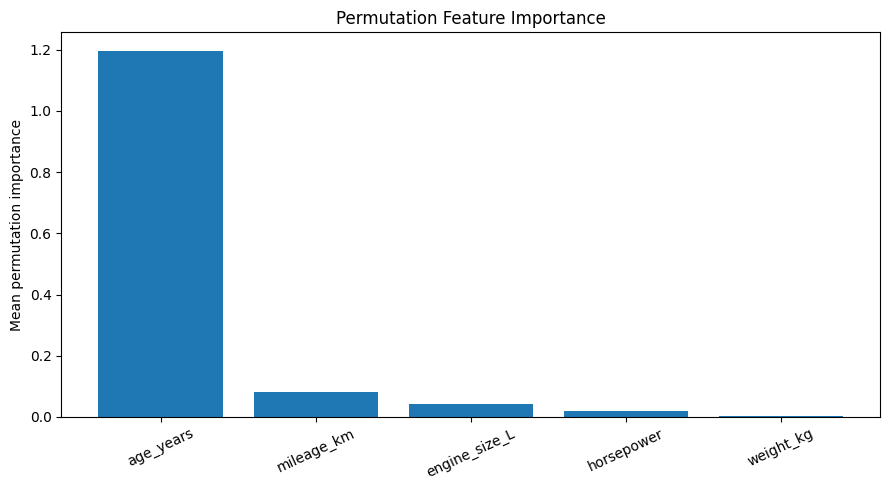

In [5]:
plt.figure(figsize=(9,5))
plt.bar(perm_df["Feature"], perm_df["Importance"])
plt.xticks(rotation=25)
plt.ylabel("Mean permutation importance")
plt.title("Permutation Feature Importance")
plt.tight_layout()
plt.show()

/tmp/ipykernel_1373/412522565.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, show=False)


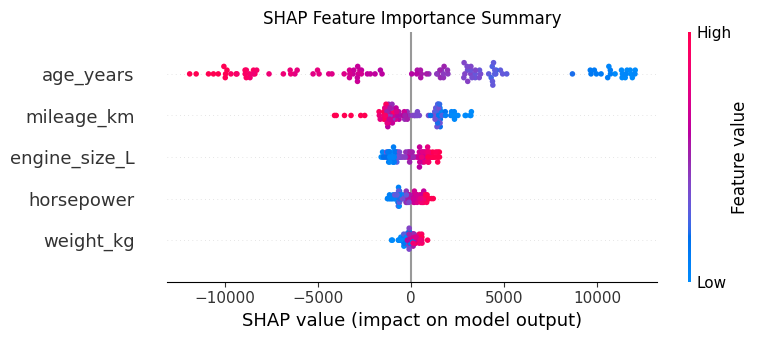

In [6]:
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Feature Importance Summary")
plt.tight_layout()
plt.show()